In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('US_honey_dataset.csv')
df

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


# EDA
Exploratory Data Analysis

In [3]:
df.columns

Index(['Unnamed: 0', 'state', 'colonies_number', 'yield_per_colony',
       'production', 'stocks', 'average_price', 'value_of_production', 'year'],
      dtype='object')

In [4]:
df.drop(columns='Unnamed: 0', inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                1115 non-null   object 
 1   colonies_number      1115 non-null   int64  
 2   yield_per_colony     1115 non-null   int64  
 3   production           1115 non-null   int64  
 4   stocks               1115 non-null   int64  
 5   average_price        1115 non-null   float64
 6   value_of_production  1115 non-null   int64  
 7   year                 1115 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 69.8+ KB


In [6]:
df.describe()

,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
count,1115.000000,1115.000000,1.115000e+03,1.115000e+03,1115.000000,1.115000e+03,1115.000000
mean,62438.565022,59.743498,2.851268e+06,1.172625e+06,140.623076,5.667412e+06,2007.740807
std,92648.175955,19.940500,5.561202e+06,2.049556e+06,107.011544,9.459460e+06,7.823002
min,2000.000000,19.000000,1.200000e+04,9.000000e+03,1.300000,1.060000e+05,1995.000000
25%,9000.000000,45.000000,2.460000e+05,1.125000e+05,70.000000,1.008000e+06,2001.000000
50%,26000.000000,57.000000,8.280000e+05,3.700000e+05,128.000000,2.281000e+06,2008.000000
75%,69000.000000,71.000000,2.700000e+06,1.253500e+06,193.000000,5.704000e+06,2015.000000
max,550000.000000,155.000000,3.906000e+07,1.354500e+07,874.000000,8.385900e+07,2021.000000


In [7]:
df.isnull().sum()

,0
state,0
colonies_number,0
yield_per_colony,0
production,0
stocks,0
average_price,0
value_of_production,0
year,0


In [8]:
df.duplicated().sum()

np.int64(0)



---



Ql- Which state is having the highest honey production through out all these years. (represent it using a bar graph)

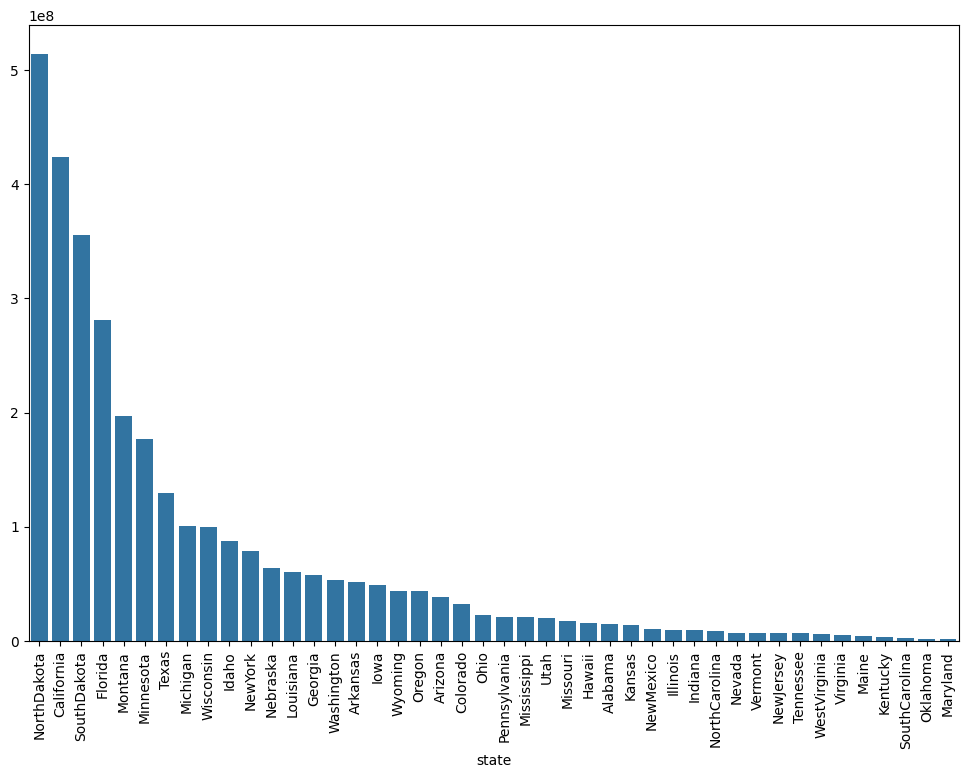

In [9]:
df1 = df.groupby('state')['production'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=df1.index, y=df1.values)
plt.xticks(rotation=90)
plt.show()

In [10]:
df1 = df.groupby('state')['production'].sum().sort_values(ascending=False).reset_index()
df1

,state,production
0,NorthDakota,513742000
1,California,423876000
2,SouthDakota,355726000
3,Florida,280934000
4,Montana,197173000
5,Minnesota,176581000
6,Texas,129441000
7,Michigan,101063000
8,Wisconsin,99909000
9,Idaho,87188000


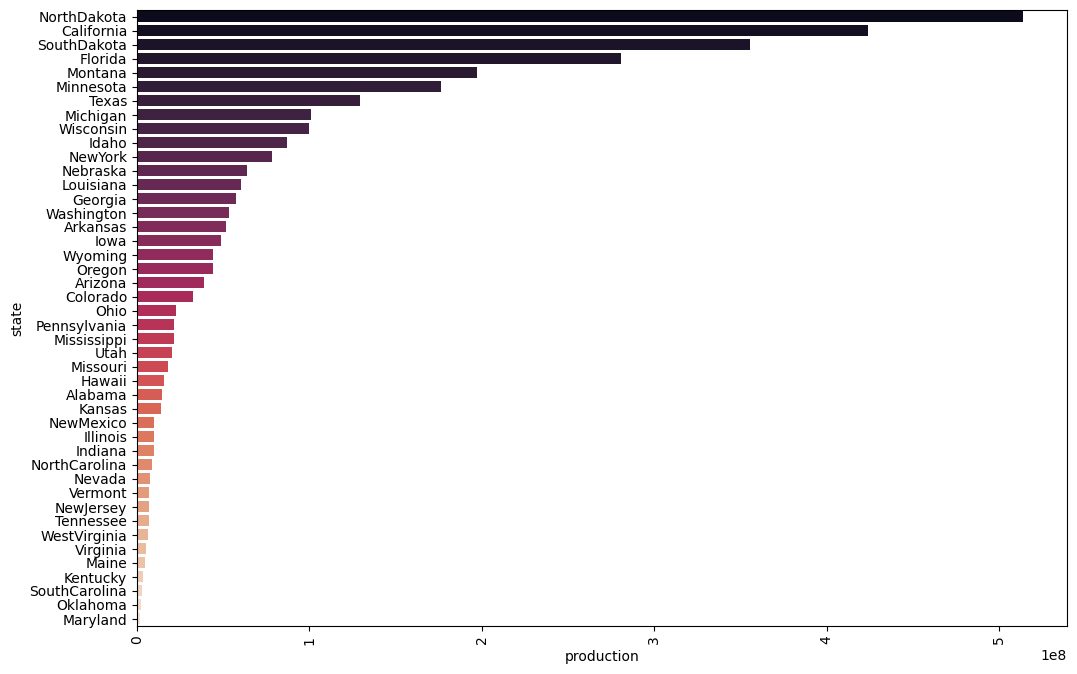

In [11]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df1, x='production', y='state', hue='state', palette='rocket')
plt.xticks(rotation=90)
plt.show()

North Dakota is the highest honey production state.


---



Q2 Which state is having the highest and lowest yield_per_colony?(represent it using bar graph).

In [12]:
df1 = df.groupby('state')['yield_per_colony'].sum().sort_values(ascending=False).reset_index()
df1

,state,yield_per_colony
0,Hawaii,2802
1,Louisiana,2506
2,Mississippi,2341
3,NorthDakota,2266
4,Montana,2148
5,Florida,1956
6,SouthDakota,1950
7,Texas,1921
8,Wisconsin,1896
9,Arkansas,1886


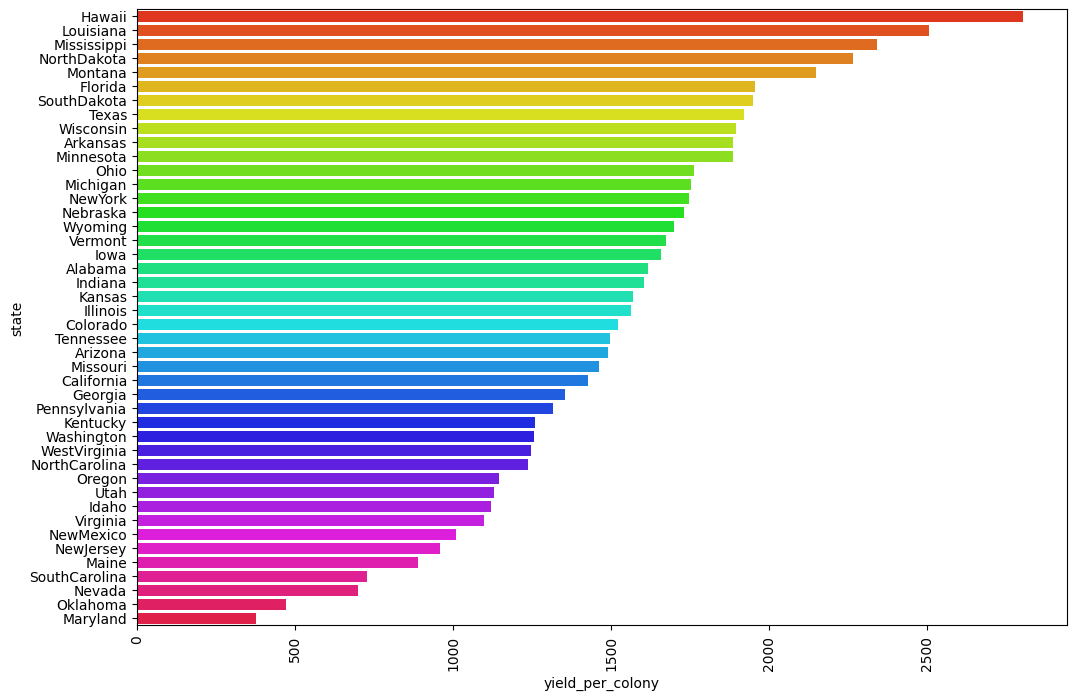

In [13]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df1, x='yield_per_colony', y='state', hue='state', palette='hsv')
plt.xticks(rotation=90)
plt.show()

Hawaii is the highest and Maryland is the lowest yield per colony.

---



Q3. Which year witnesses the highest profit in honey Production?(represent it using bar graph).

In [14]:
df1 = df.groupby('year')['production'].sum().sort_values(ascending=False).reset_index()
df1

,year,production
0,2000,220320000
1,1998,219321000
2,1995,210272000
3,1999,204585000
4,1996,197995000
5,1997,191176000
6,2001,185403000
7,2004,182379000
8,2003,180741000
9,2005,173857000


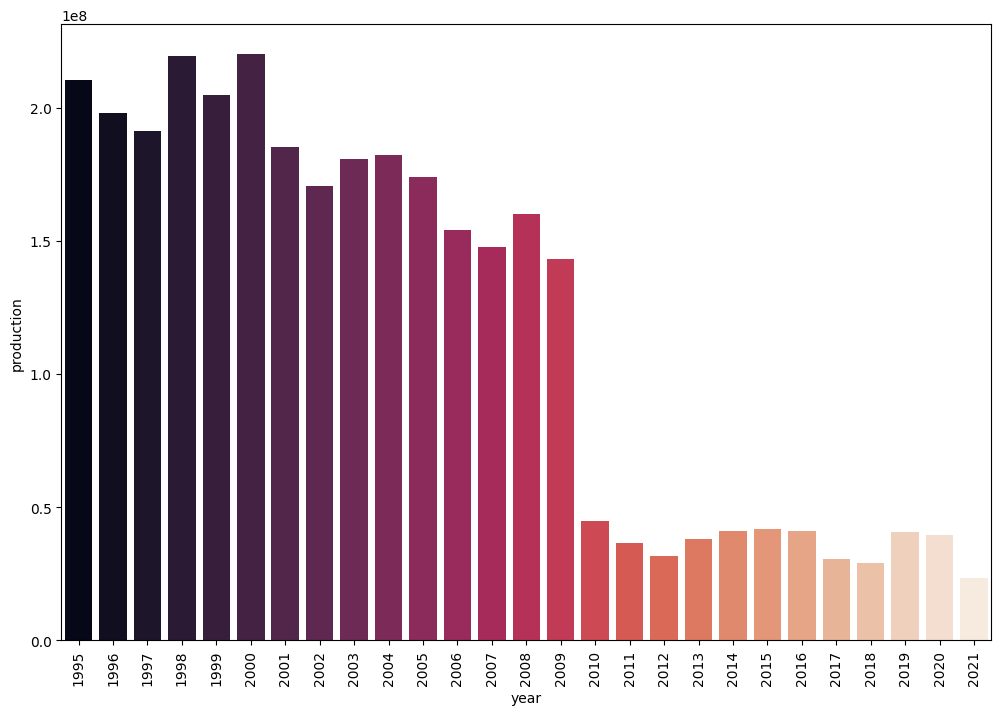

In [15]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df1, y='production', x='year', hue='year', palette='rocket', legend=False)
plt.xticks(rotation=90)
plt.show()

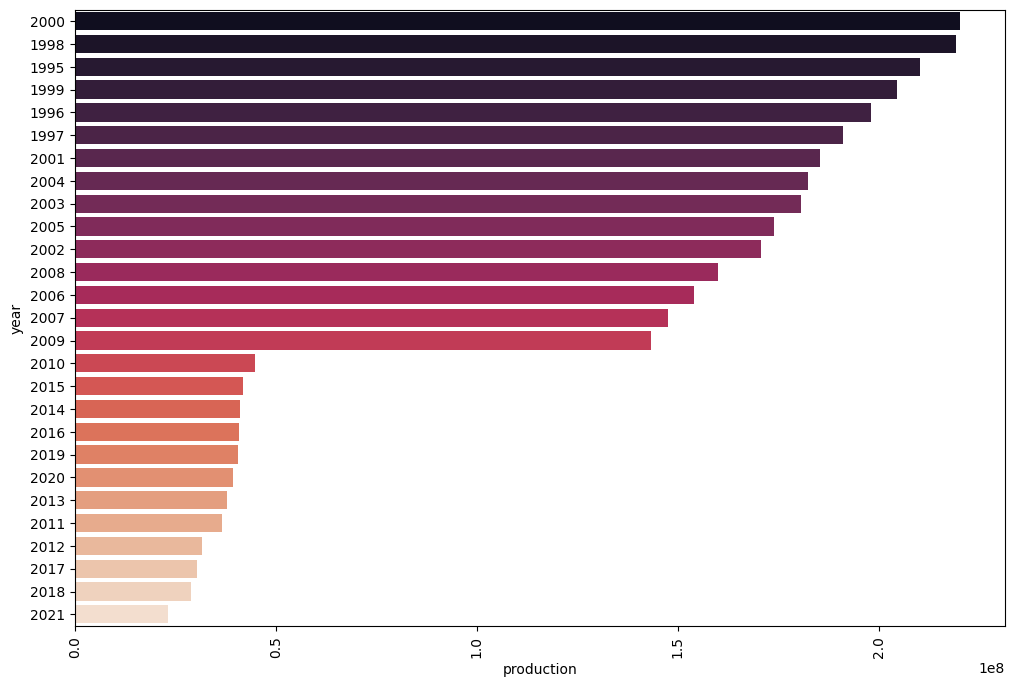

In [16]:
df1 = df.groupby('year')['production'].sum().sort_values(ascending=False).reset_index()
df1['year'] = pd.Categorical(df1['year'], categories=df1['year'], ordered=True)

plt.figure(figsize=(12, 8))
sns.barplot(data=df1, x='production', y='year', hue='year', palette='rocket', legend=False)
plt.xticks(rotation=90)
plt.show()



---



Q4. which state was having highest stock in 2020? represent it using bar graph

In [41]:
df1=df[df['year']==2020]
df1.sort_values(by='stocks',ascending=False)


,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
1065,SouthDakota,245000,61,8668000,8668000,1.77,26453000,2020
1060,NorthDakota,495000,78,8108000,8108000,1.59,61390000,2020
1055,Montana,110000,81,3208000,3208000,1.61,14345000,2020
1038,California,320000,43,2752000,2752000,1.95,26832000,2020
1052,Minnesota,108000,55,2495000,2495000,1.80,10692000,2020
1051,Michigan,95000,47,1384000,1384000,2.95,13172000,2020
1046,Iowa,35000,58,1259000,1259000,2.54,5156000,2020
1067,Texas,157000,57,1253000,1253000,2.00,17898000,2020
1062,Oregon,95000,29,1102000,1102000,2.40,6612000,2020
1040,Florida,192000,46,883000,883000,2.24,19784000,2020


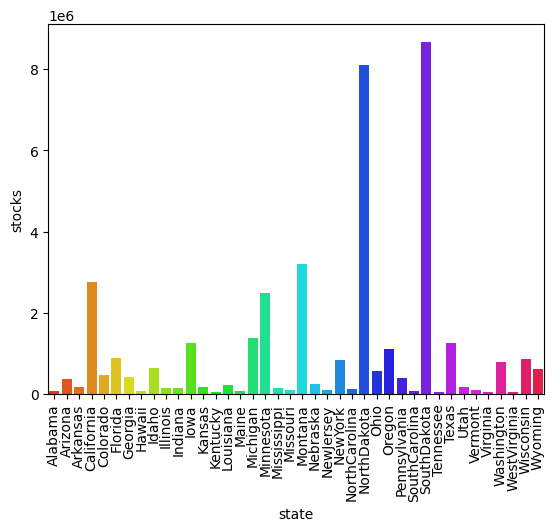

In [44]:
sns.barplot(data=df1,x='state',y='stocks',palette='hsv',hue='state')
plt.xticks(rotation=90)
plt.show()

SouthDakota

---



Q5 Which state is having the highest average price in 21st century?

In [50]:
df_2020=df[df['year']>=2020]
df1 = df_2020.groupby('state')['average_price'].mean().sort_values(ascending=False).reset_index()
df1

,state,average_price
0,Virginia,7.130
1,NorthCarolina,6.170
2,Alabama,5.755
3,Illinois,5.740
4,Kentucky,5.180
5,Tennessee,4.615
6,SouthCarolina,4.380
7,WestVirginia,4.305
8,Indiana,3.900
9,NewJersey,3.795


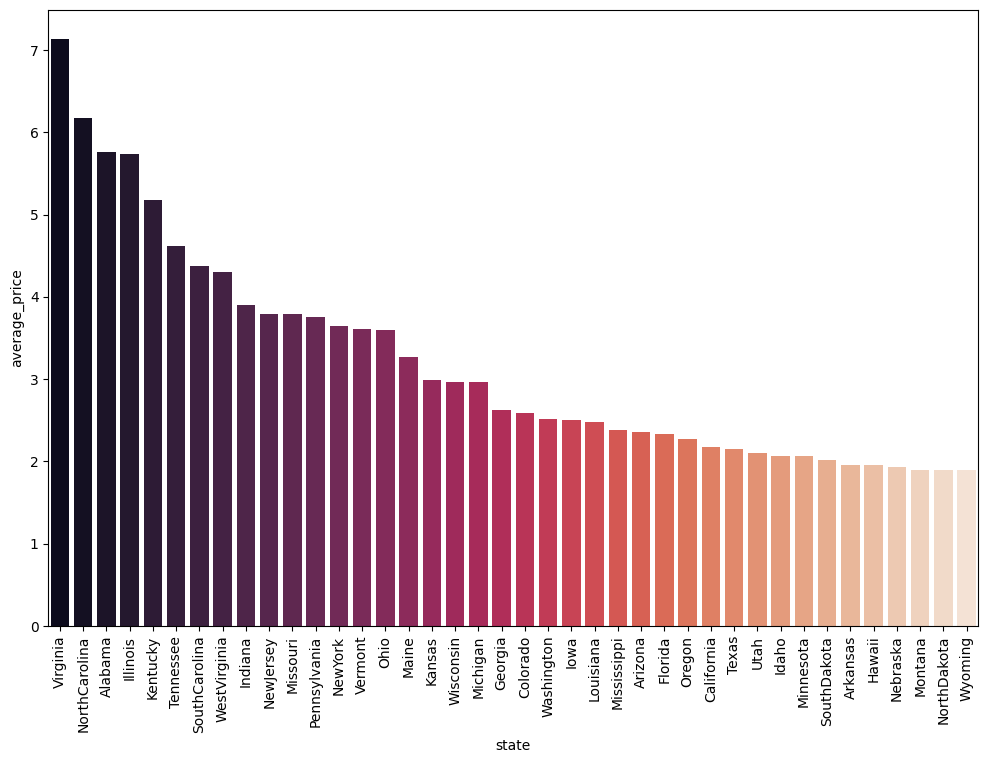

In [51]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df1, y='average_price', x='state', hue='state', palette='rocket', legend=False)
plt.xticks(rotation=90)
plt.show()

Virginia

---

